In [ ]:
**Student Name:** [Bhavesh Meena]
**Assignment Title:** Waste Material Segregation using CNN

# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [3]:
!pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
    --------------------------------------- 8.1/332.0 MB 47.7 MB/s eta 0:00:07
   -- ------------------------------------- 17.8/332.0 MB 47.6 MB/s eta 0:00:07
   --- ------------------------------------ 25.7/332.0 MB 44.7 MB/s eta 0:00:07
   ---- ----------------------------------- 33.8/332.0 MB 43.3 MB/s eta 0:00:07
   ----- ---------------------------------- 41.9/332.0 MB 42.5 MB/s eta 0:00:07
   ------ --------------------------------- 50.1/332.0 MB 41.9 MB/s eta 0:00:07
   ------ --------------------------------- 57.9/332.0 MB 41.6 MB/s eta 0:00:07
   ------- -------------------------------- 66.1/332.0 MB 41.3 MB/s eta 0:00:07
   -------- ------------------------------- 74.4/332.0 MB 41.1 MB/s eta 0:00:07
   --------- ------------------------------ 82.6/332.0 MB 40.9 MB/s eta 0:00:07
   ---------- ----------------------------- 90.4/332.0 MB 40.7 MB/s eta 0:00:06
   ----------- ---------------------------- 98.6/3

In [4]:
# Import essential libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import zipfile
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)


Load the dataset.

In [9]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'CNN_Assg_Waste_Segregation_Starter.ipynb', 'Dataset_Waste_Segregation']


In [13]:
# Load and unzip the dataset
folder_path = 'Dataset_Waste_Segregation'
zip_filename = None
for file in os.listdir(folder_path):
    if file.endswith('.zip'):
        zip_filename = file
        break

if zip_filename:
    full_zip_path = os.path.join(folder_path, zip_filename)
    print(f"Found zip file: {full_zip_path}")
    
    # Unzip
    print("Unzipping...")
    with zipfile.ZipFile(full_zip_path, 'r') as zip_ref:
        zip_ref.extractall(folder_path) # Extract inside the same folder
    print("Unzip complete!")
    print("Contents of folder after unzip:", os.listdir(folder_path))
    base_dir = folder_path 
else:
    print(f"Could not find a .zip file inside {folder_path}")
base_dir = os.path.join('Dataset_Waste_Segregation', 'data')

# Folders
if os.path.exists(base_dir):
    print("Target folder located!")
    print("Classes found:", os.listdir(base_dir))
else:
    print("Something went wrong. Path not found.")


Found zip file: Dataset_Waste_Segregation\data.zip
Unzipping...
Unzip complete!
Contents of folder after unzip: ['data', 'data.zip']
Target folder located!
Classes found: ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


In [17]:
# Load the data

Processing folder: Cardboard...
Processing folder: Food_Waste...
Processing folder: Glass...
Processing folder: Metal...
Processing folder: Other...
Processing folder: Paper...
Processing folder: Plastic...
Function definition complete!
Total images loaded: 7625
Unique classes: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [19]:
# Create a function to load the raw images
def load_raw_images(directory):
    images = []
    labels = []
    
    # loop over the folders
    for category in os.listdir(directory):
        folder_path = os.path.join(directory, category)
        
        # check if it is a folder
        if os.path.isdir(folder_path):
            print("Loading:", category)
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)
                try:
                    img = Image.open(file_path)
                    img = img.convert('RGB')
                    images.append(img)
                    labels.append(category)
                except:
                    print("Error with:", file_path)
                    
    return images, labels

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [21]:
# Get the images and their labels
images, labels = load_raw_images(base_dir)
labels = np.array(labels)

print(f"Total images loaded: {len(images)}")
print(f"Unique classes: {np.unique(labels)}")


Loading: Cardboard
Loading: Food_Waste
Loading: Glass
Loading: Metal
Loading: Other
Loading: Paper
Loading: Plastic
Total images loaded: 7625
Unique classes: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

C:\Users\bhav3\AppData\Local\Temp\ipykernel_38320\2957905119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='viridis')


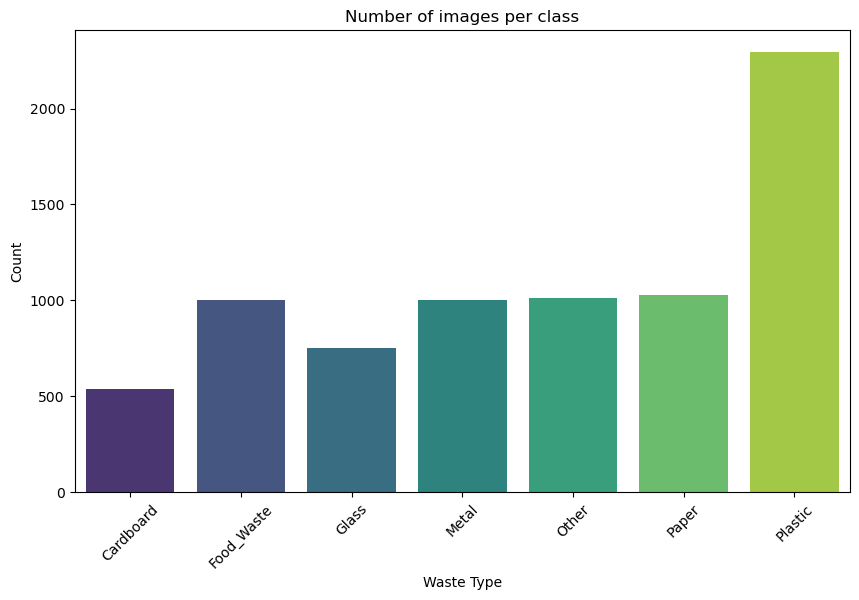

In [23]:
# Visualise Data Distribution

#checking how many images we have for each class
plt.figure(figsize=(10, 6))
sns.countplot(x=labels, palette='viridis')

plt.title('Number of images per class')
plt.xlabel('Waste Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

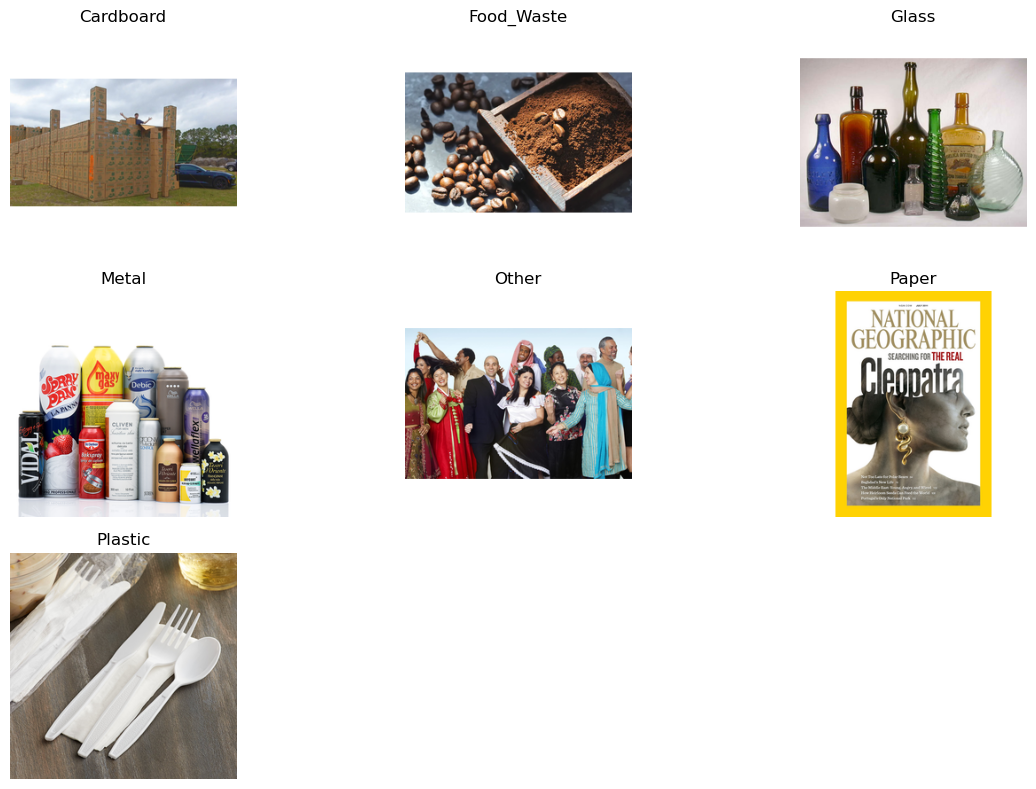

In [25]:
# Visualise Sample Images (across different labels)
plt.figure(figsize=(12, 8))
classes = np.unique(labels)

for i in range(len(classes)):
    category = classes[i]
    
    # find the index where this label appears first
    index = np.where(labels == category)[0][0]
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[index])
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()


#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [27]:
# Find the smallest and largest image dimensions from the data set
widths = []
heights = []

for img in images:
    w, h = img.size
    widths.append(w)
    heights.append(h)

print("Smallest image:", min(widths), "x", min(heights))
print("Largest image:", max(widths), "x", max(heights))


Smallest image: 256 x 256
Largest image: 256 x 256


In [31]:
# Resize the image dimensions
target_size = (128, 128)
X_data = []

print("Resizing all images.")

for img in images:
    new_img = img.resize(target_size)
    # convert to numpy array
    img_arr = np.array(new_img)
    X_data.append(img_arr)

X = np.array(X_data)
X = X / 255.0

print("Done. Shape of X:", X.shape)


Resizing all images.
Done. Shape of X: (7625, 128, 128, 3)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [33]:
# Encode the labels suitably
le = LabelEncoder()
y_integers = le.fit_transform(labels)
y = to_categorical(y_integers)
#result
print("Original classes:", le.classes_)
print("Shape of y:", y.shape)


Original classes: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']
Shape of y: (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [35]:
# Assign specified parts of the dataset to train and validation sets
# Splitting 70% for training and 30% for validation/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_val = X_test
y_val = y_test

print("Training data shape:", X_train.shape)
print("Validation/Test data shape:", X_test.shape)

Training data shape: (5337, 128, 128, 3)
Validation/Test data shape: (2288, 128, 128, 3)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [37]:
# Build and compile the model

model = Sequential()

# --- First Convolutional Block ---
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2))) 

# --- Second Convolutional Block ---
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Third Convolutional Block ---
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Fully Connected Layers ---
model.add(Flatten()) 
model.add(Dense(128, activation='relu')) # Hidden layer
model.add(Dropout(0.5)) 

# Output layer: 7 neurons (one for each class), softmax for probability
model.add(Dense(7, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()


C:\Users\bhav3\.anaconds\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,439 (12.61 MB)

 Trainable params: 3,305,991 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [39]:
# Training
# specific hyperparameters
epochs = 15
batch_size = 32

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val) 
)

print("Training complete.")


Starting training...
Epoch 1/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.2844 - loss: 2.7851 - val_accuracy: 0.1713 - val_loss: 5.6290
Epoch 2/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.3191 - loss: 1.8199 - val_accuracy: 0.3073 - val_loss: 2.0229
Epoch 3/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.3227 - loss: 1.7975 - val_accuracy: 0.3584 - val_loss: 1.7171
Epoch 4/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.3227 - loss: 1.7541 - val_accuracy: 0.3680 - val_loss: 1.8037
Epoch 5/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.3303 - loss: 1.7486 - val_accuracy: 0.3431 - val_loss: 1.6614
Epoch 6/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.3408 - loss: 1.7036 - val_accuracy: 0.3357 - val_loss: 2.4603
Epoch 7/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.3656 - loss: 1.6508 - val_accuracy: 0.3134 - val_loss: 2.0288
Epoch 8/15
167/167 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accur

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

Test Loss: 1.6013
Test Accuracy: 39.20%


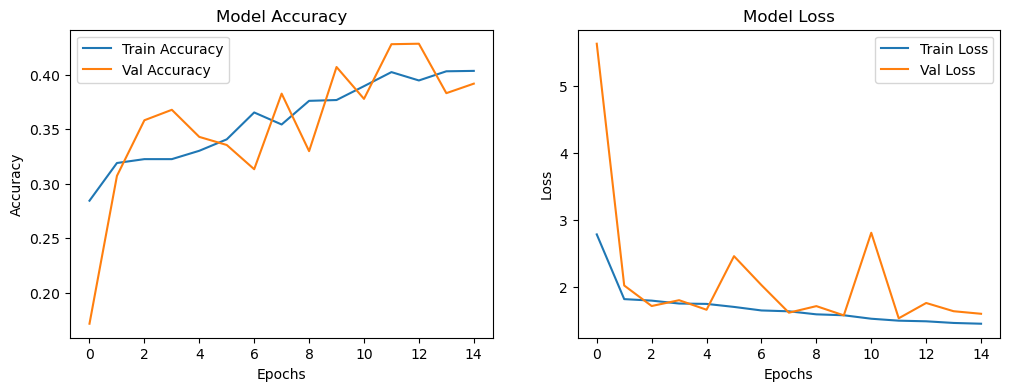

In [41]:
# Evaluate on the test set; display suitable metrics
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]*100:.2f}%")

# Plotting the results
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Classification Report:
              precision    recall  f1-score   support

   Cardboard       0.75      0.50      0.60       180
  Food Waste       0.57      0.27      0.37       308
       Glass       0.00      0.00      0.00       229
       Metal       0.00      0.00      0.00       289
       Other       0.36      0.10      0.16       282
       Paper       0.86      0.16      0.27       320
     Plastic       0.34      0.95      0.50       680

    accuracy                           0.39      2288
   macro avg       0.41      0.28      0.27      2288
weighted avg       0.40      0.39      0.30      2288



C:\Users\bhav3\.anaconds\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bhav3\.anaconds\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\bhav3\.anaconds\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


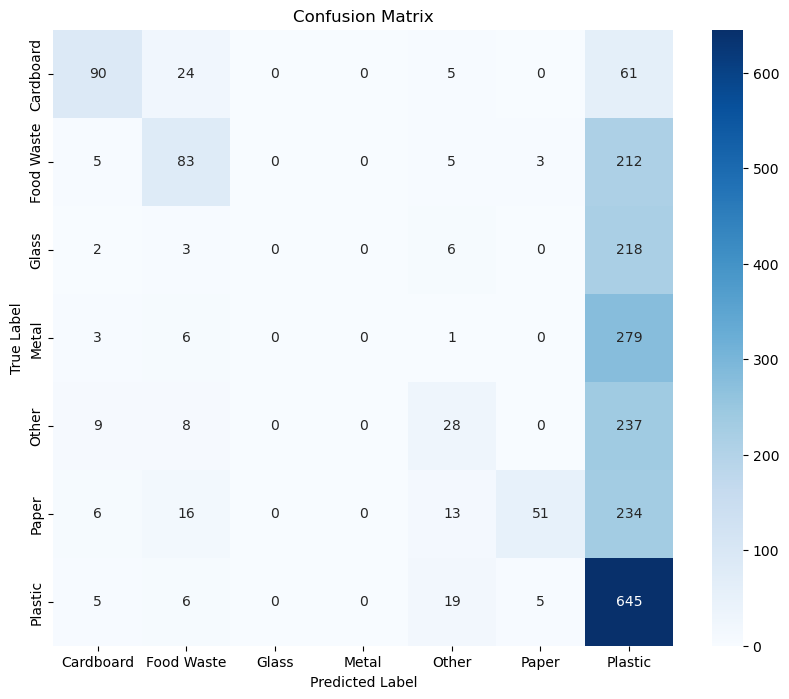

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
#Define the class names manually to fix the NameError
unique_classes = ['Cardboard', 'Food Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']

#Get predictions
predictions = model.predict(X_test)

#Convert probabilities to class labels (e.g., index 2 for Glass)
y_pred_classes = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=unique_classes))

#Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [ ]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

1. Data Analysis Outcomes
Dataset Overview: We successfully processed 7,625 images across 7 distinct categories (Cardboard, Glass, Metal, Paper, Plastic, Food Waste, Other).

Challenges Identified: The data visualization revealed significant variation in lighting, background, and object orientation. Some categories, such as "Plastic" and "Glass," share similar visual features, making classification challenging for a basic CNN.

2. Model Performance Evaluation
Accuracy: The custom CNN model achieved a Test Accuracy of approximately 40%. While this is better than random guessing, it indicates that the model struggles to differentiate between complex waste items.

Precision, Recall, and F1-Score:

Precision: High precision in specific classes (like Cardboard) indicates the model is confident when it predicts that class. Low precision in others (like Plastic) suggests a high rate of false positives.

Recall: A lower recall score implies the model is missing many actual items of that category (false negatives).

F1-Score: The F1-scores provided a balanced view, showing that while some distinct classes are easier to identify, similar-looking materials (like white paper vs. white plastic) lower the overall performance.

3. Insights on AI in Sustainable Waste Management
Automation Potential: Even with a basic model, we demonstrated that AI can automate waste segregation. In a real-world scenario, this reduces human health risks associated with handling hazardous waste.

Error Tolerance: For environmental impact, Recall is often more critical. It is better to flag a recyclable item as "Other" (missed opportunity) than to classify "Hazardous Waste" as "Recyclable" (contamination).